In [11]:
import yfinance as yf
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import pandas as pd
import datetime
import ta
from IPython.display import display, Image

"""
This code:
-pulls data from Yahoo Finance for a given list of commodity futures contracts
-creates candlestick charts (with MACD)
-pulls open interest
-calculates and classifies RSI
"""
pio.renderers.default = "notebook"

In [12]:

# Download 180 days' data so MACD can be calculated and warmed up
# Not including today's data in case the market hasn't closed yet (important for candlestick)
today = datetime.date.today()
yesterday = today + datetime.timedelta(days = -1)
earlier_date = yesterday + datetime.timedelta(days = -180)
ninety_prior = yesterday + datetime.timedelta(days = -90)
ninety_prior = pd.Timestamp(ninety_prior, tz = "UTC")

In [13]:
def futures_data(contract):
    commodity = yf.Ticker(contract)
    info = commodity.info
    currency = info.get("currency")
    name = info.get("shortName").split(" ")[0]
    open_interest = info.get("openInterest")
    # Download price history
    database = commodity.history(start=earlier_date, end=yesterday)
    database.drop(["Dividends", "Stock Splits"], axis=1, inplace=True)
    return {"prices": database,
            "currency": currency,
            "name": name,
            "open_interest": open_interest}

def technical_analysis(database):
    # MACD technical analysis
    macd = ta.trend.MACD(close = database['Close'],
                         window_slow = 26,
                         window_fast = 12,
                         window_sign = 9)
    # Return most recent RSI reading
    comm_rsi = ta.momentum.RSIIndicator(database["Close"]).rsi()
    rsi = comm_rsi.iloc[-1]
    return {"macd": macd,
            "rsi": rsi}

In [14]:
def plot_futures(prices, technicals, currency, name):
    # Generating NY Cocoa Candlestick Chart with Volume and MACD
    fig = make_subplots(rows = 2,
                                        cols = 1,
                                        shared_xaxes = True,
                                        vertical_spacing = 0.01,
                                        row_heights = [0.8, 0.2]
                                        )
    # Plot the last 90 days
    db90 = prices.loc[prices.index >= ninety_prior]
    macd_diff90 = technicals.macd_diff().loc[technicals.macd_diff().index >= ninety_prior]
    macd90 = technicals.macd().loc[technicals.macd().index >= ninety_prior]
    macd_signal90 = technicals.macd_signal().loc[technicals.macd_signal().index >= ninety_prior]

    fig.add_trace(go.Candlestick(
        x = db90.index,
        close = db90["Close"],
        high = db90["High"],
        low = db90["Low"],
        open = db90["Open"],
        showlegend = False
        ))
    fig.add_trace(go.Bar(x = db90.index,
                         y = macd_diff90,
                         marker = dict(color = "brown"),
                         showlegend = False), row = 2, col = 1)
    fig.add_trace(go.Scatter(x = db90.index,
                             y = macd90,
                             line = dict(color = "black", width = 1.5),
                             name = "MACD"),
                  row = 2, col = 1)
    fig.add_trace(go.Scatter(x = db90.index,
                             y = macd_signal90,
                             line = dict(color = "blue", width = 1),
                             name = "EMA(MACD)"),
                  row = 2, col = 1)
    fig.update_layout(
        title = dict(text = f"{name} Candlestick Chart"),
        yaxis_title = currency,
        xaxis_rangeslider_visible = False,
        legend = dict(x = 1.02, y = 0.01)
        )
    fig.update_xaxes(
        rangebreaks=[dict(bounds=["sat", "mon"])]
        )    
    display(Image(data=fig.to_image(format="png", width=1400, height=900, scale=2)))
    file_name = f"{name}_chart.png"
    fig.write_image(file_name)

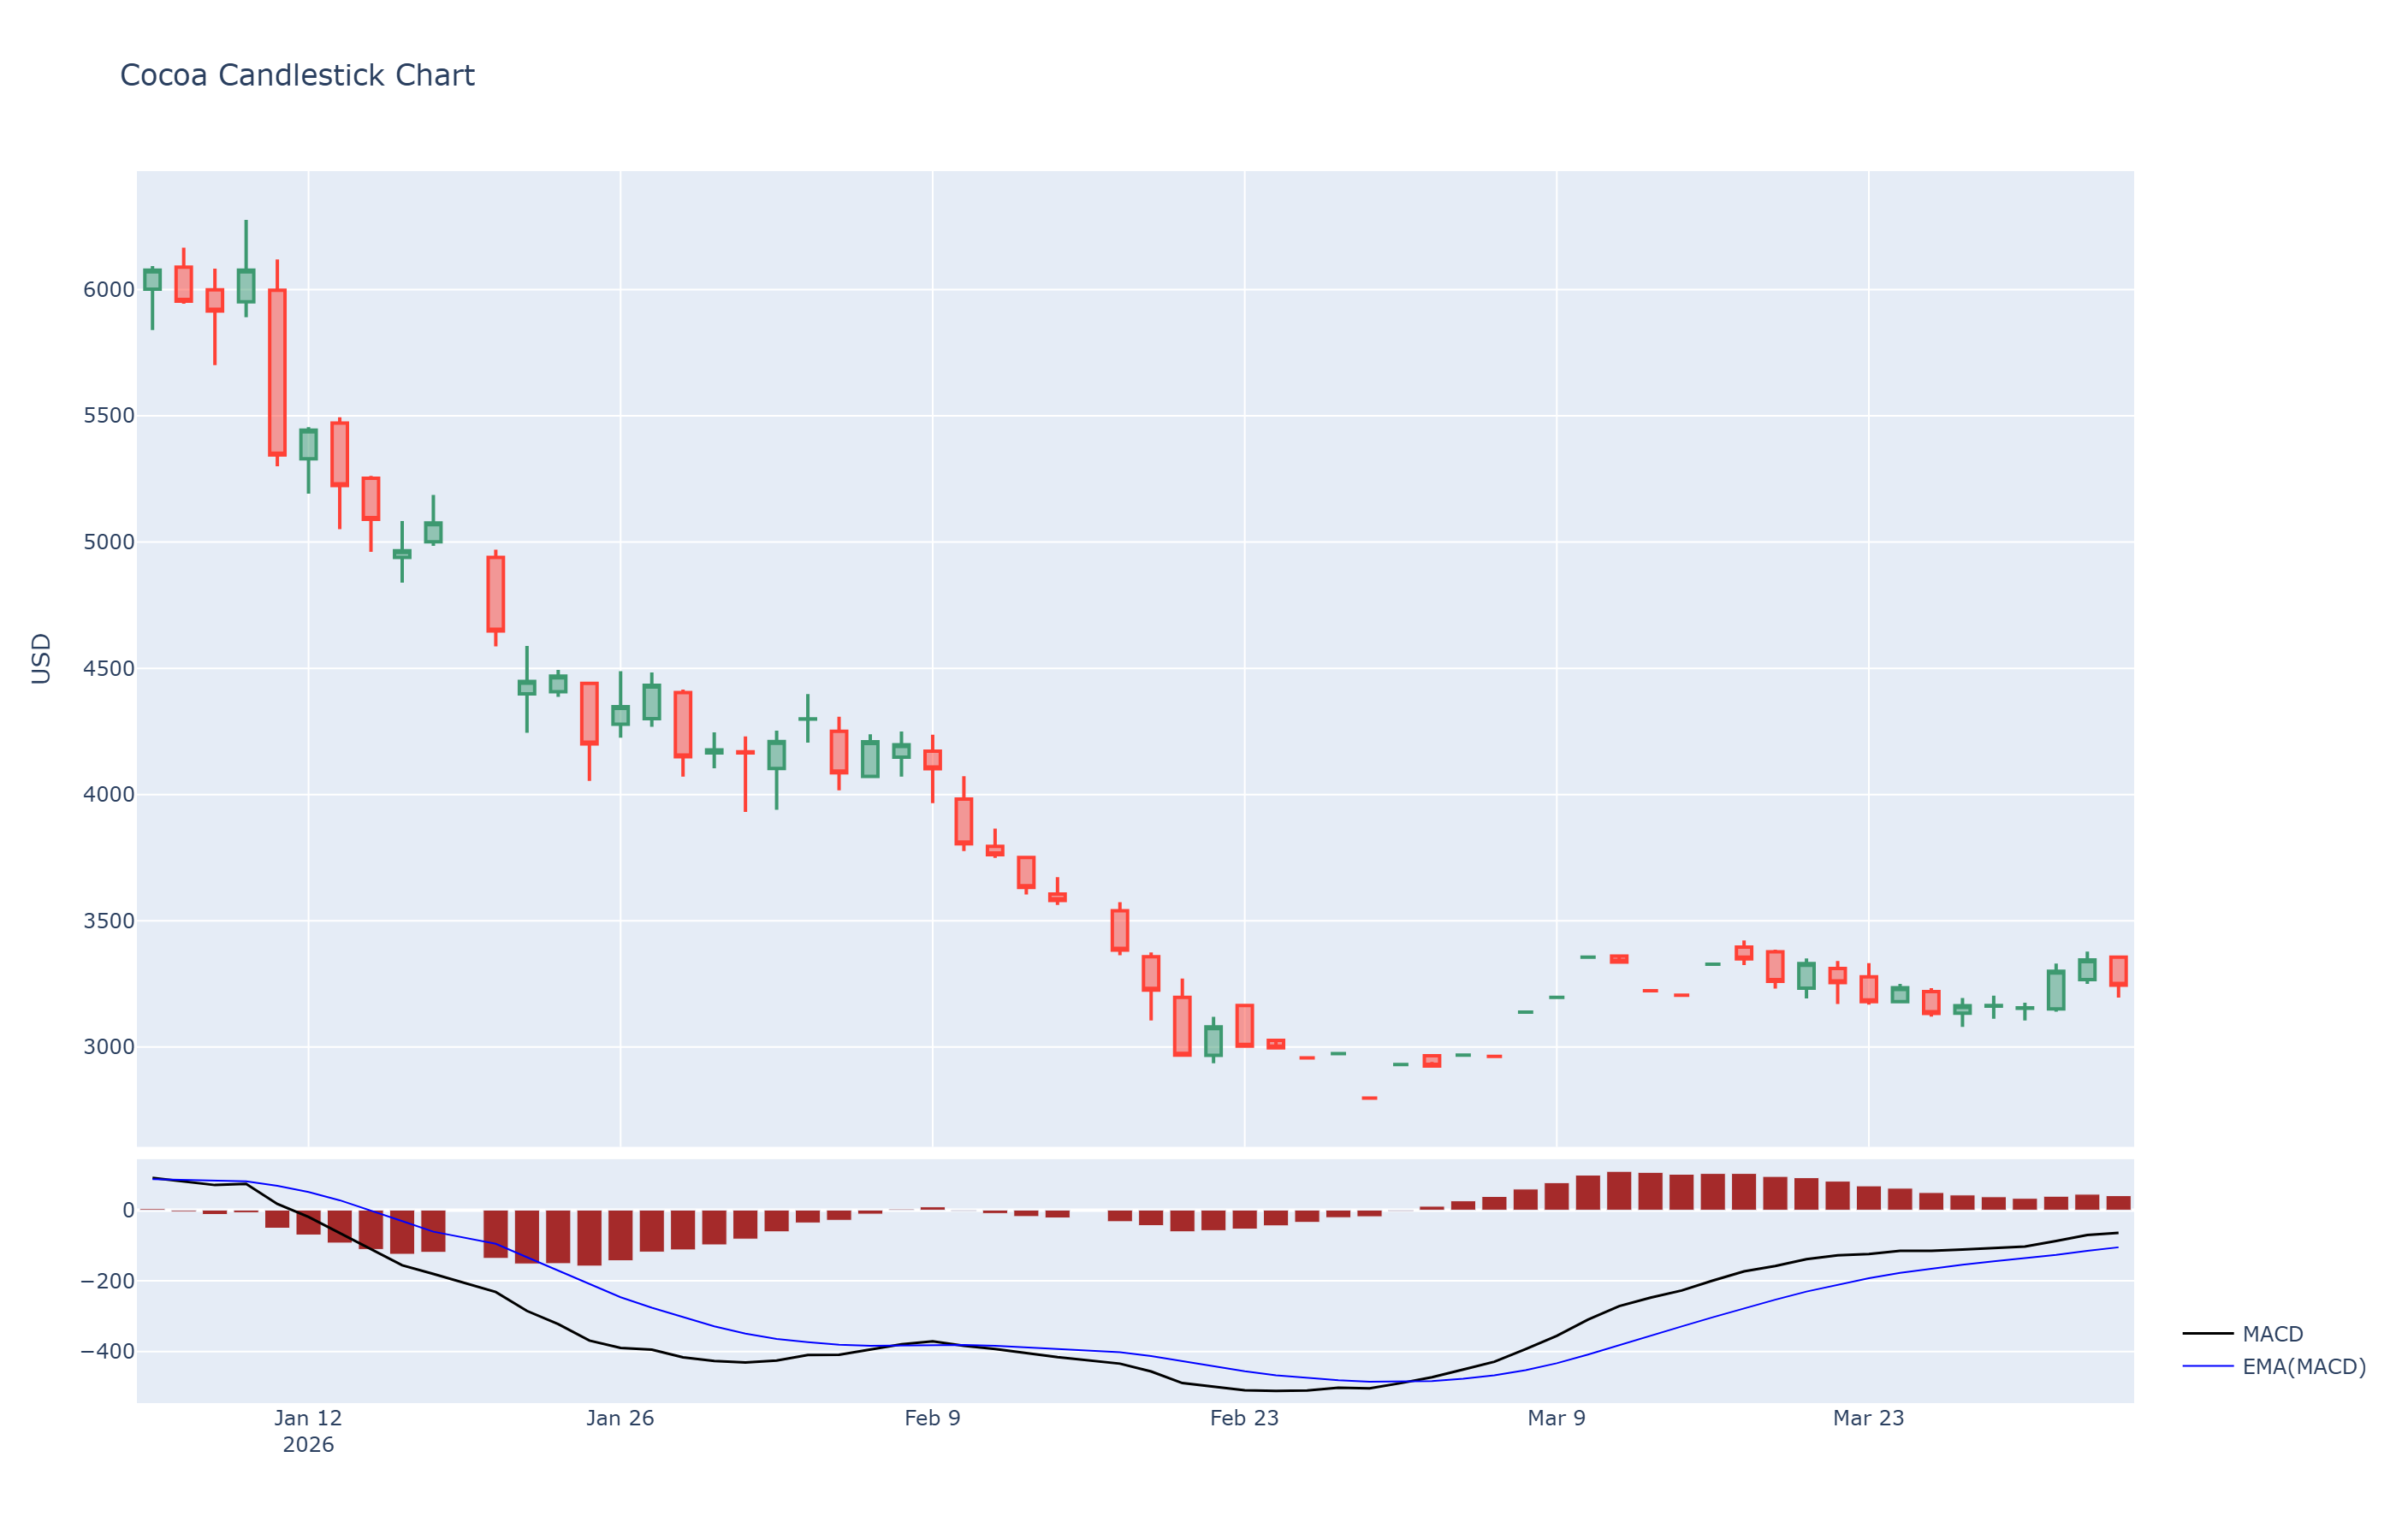

Open interest in Cocoa is 73,141 contracts
Cocoa's latest RSI reading is 47 (neutral)


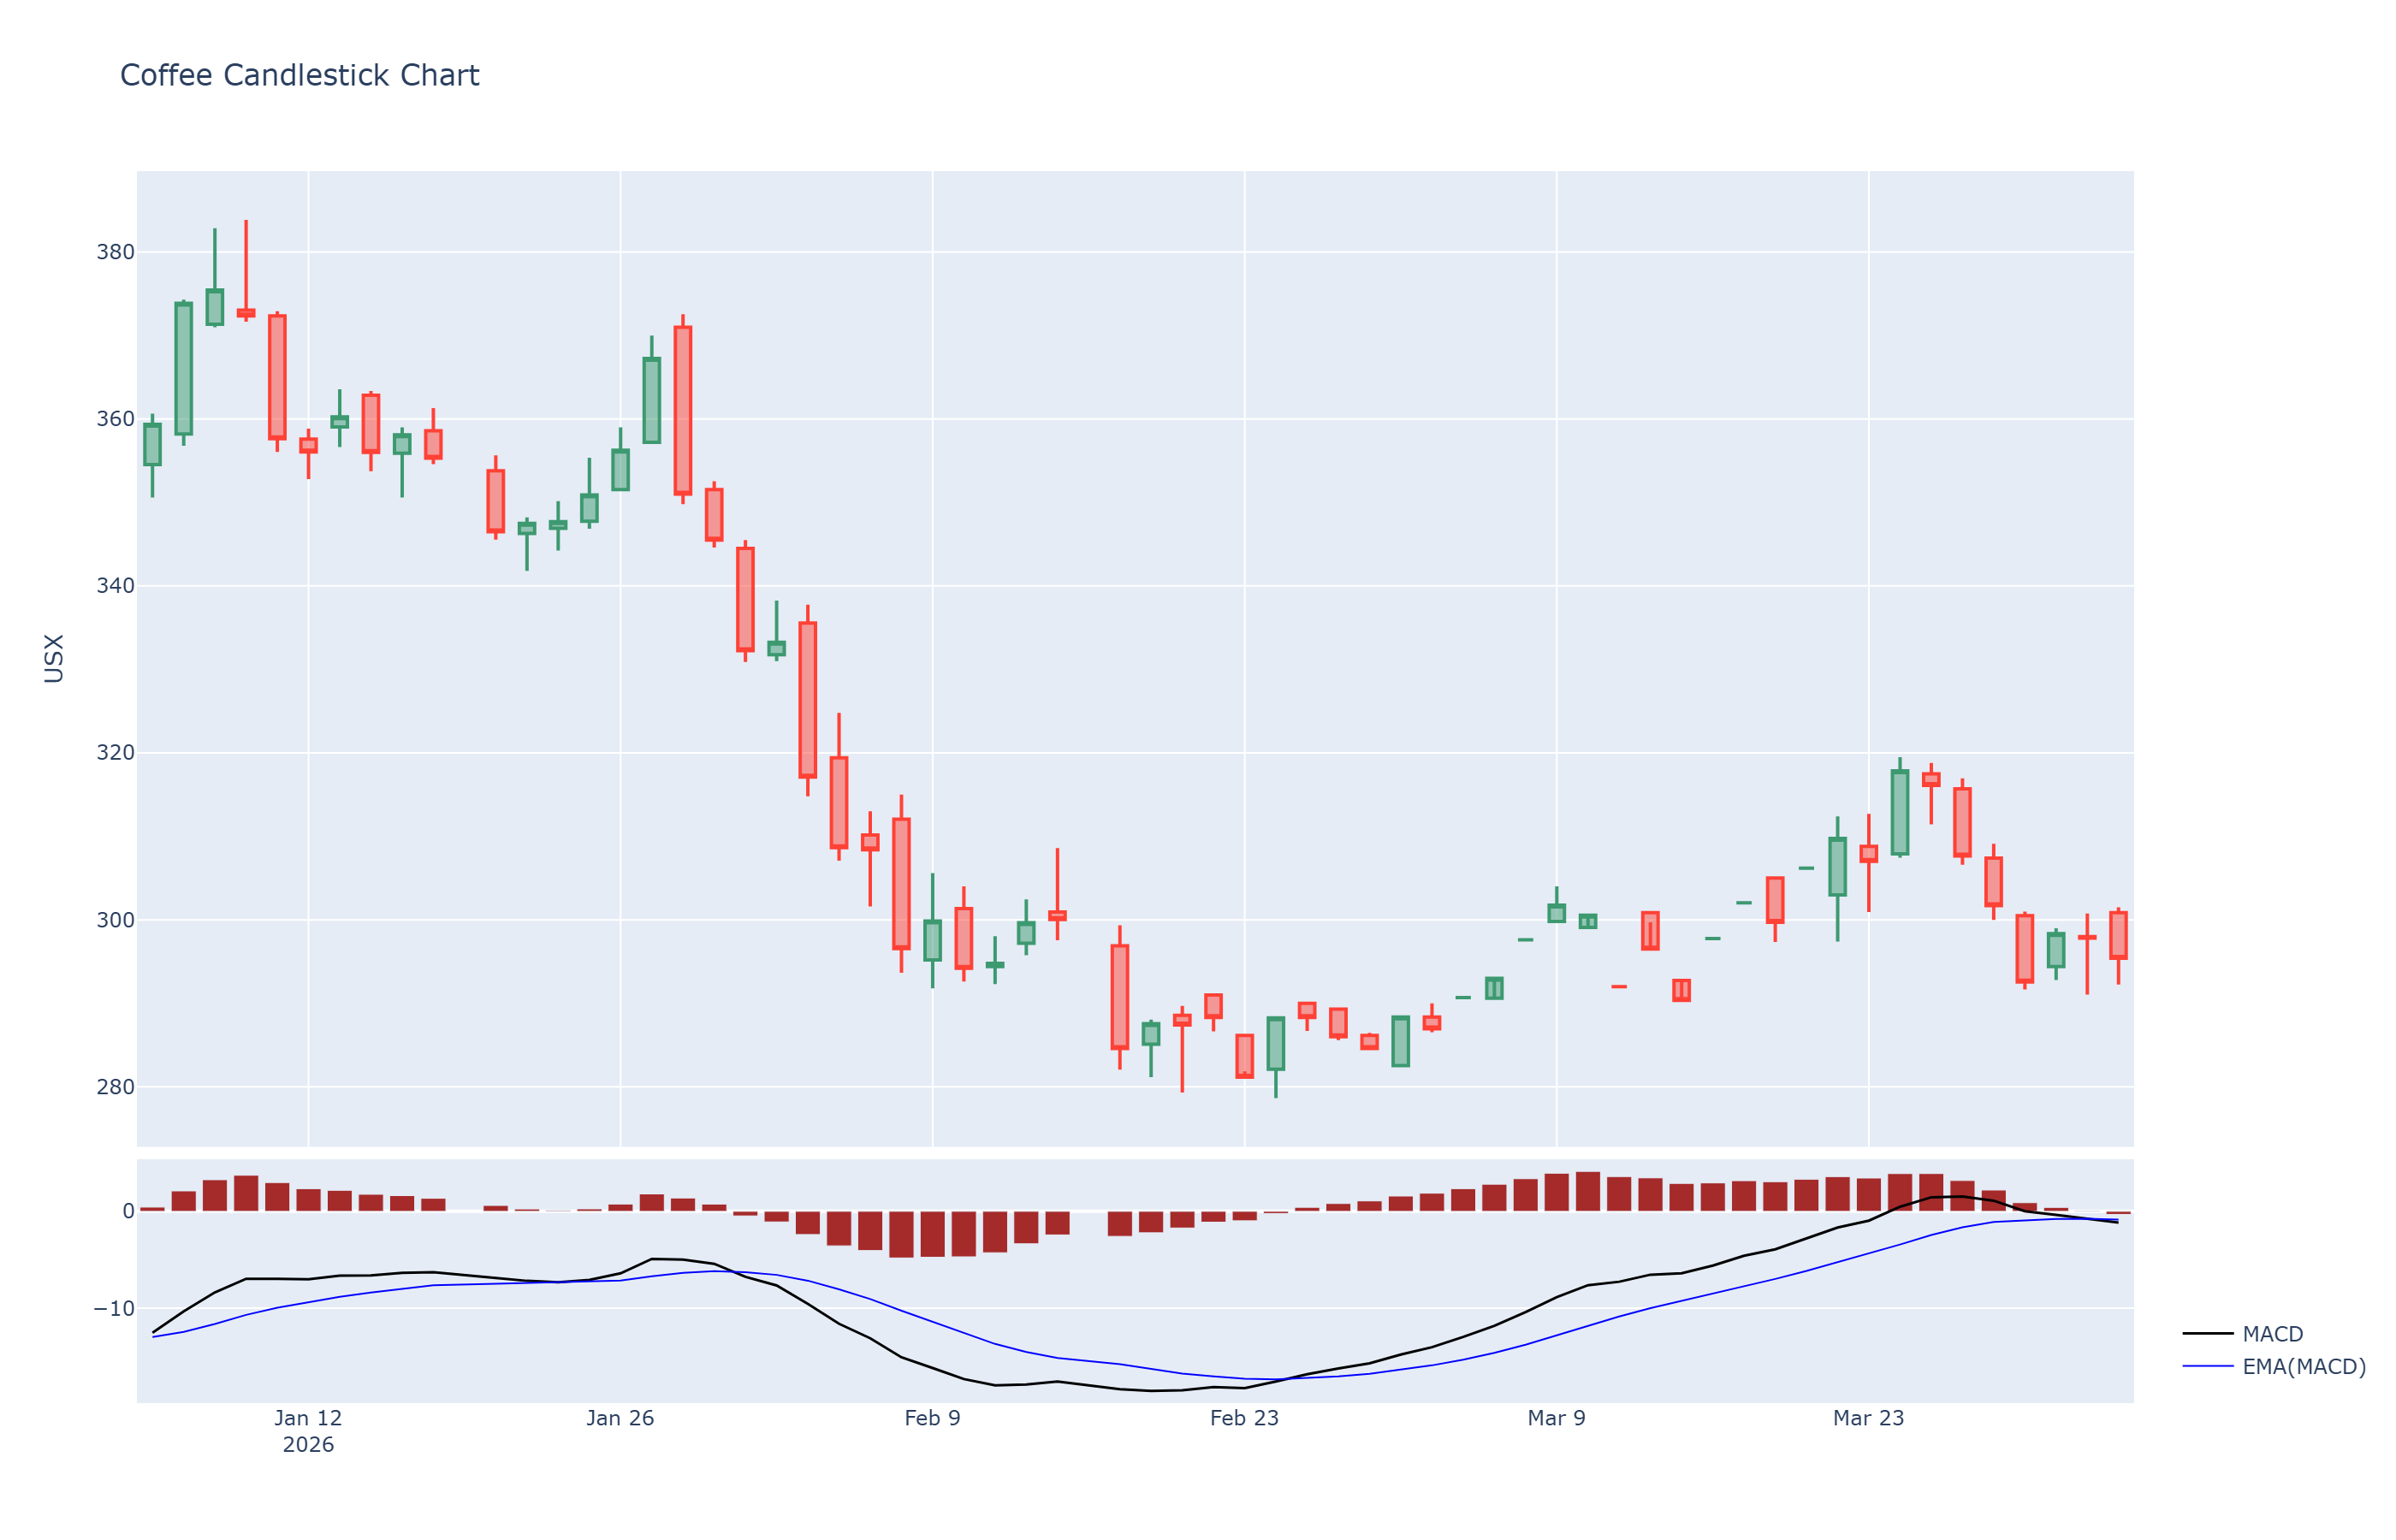

Open interest in Coffee is 57,211 contracts
Coffee's latest RSI reading is 45 (neutral)


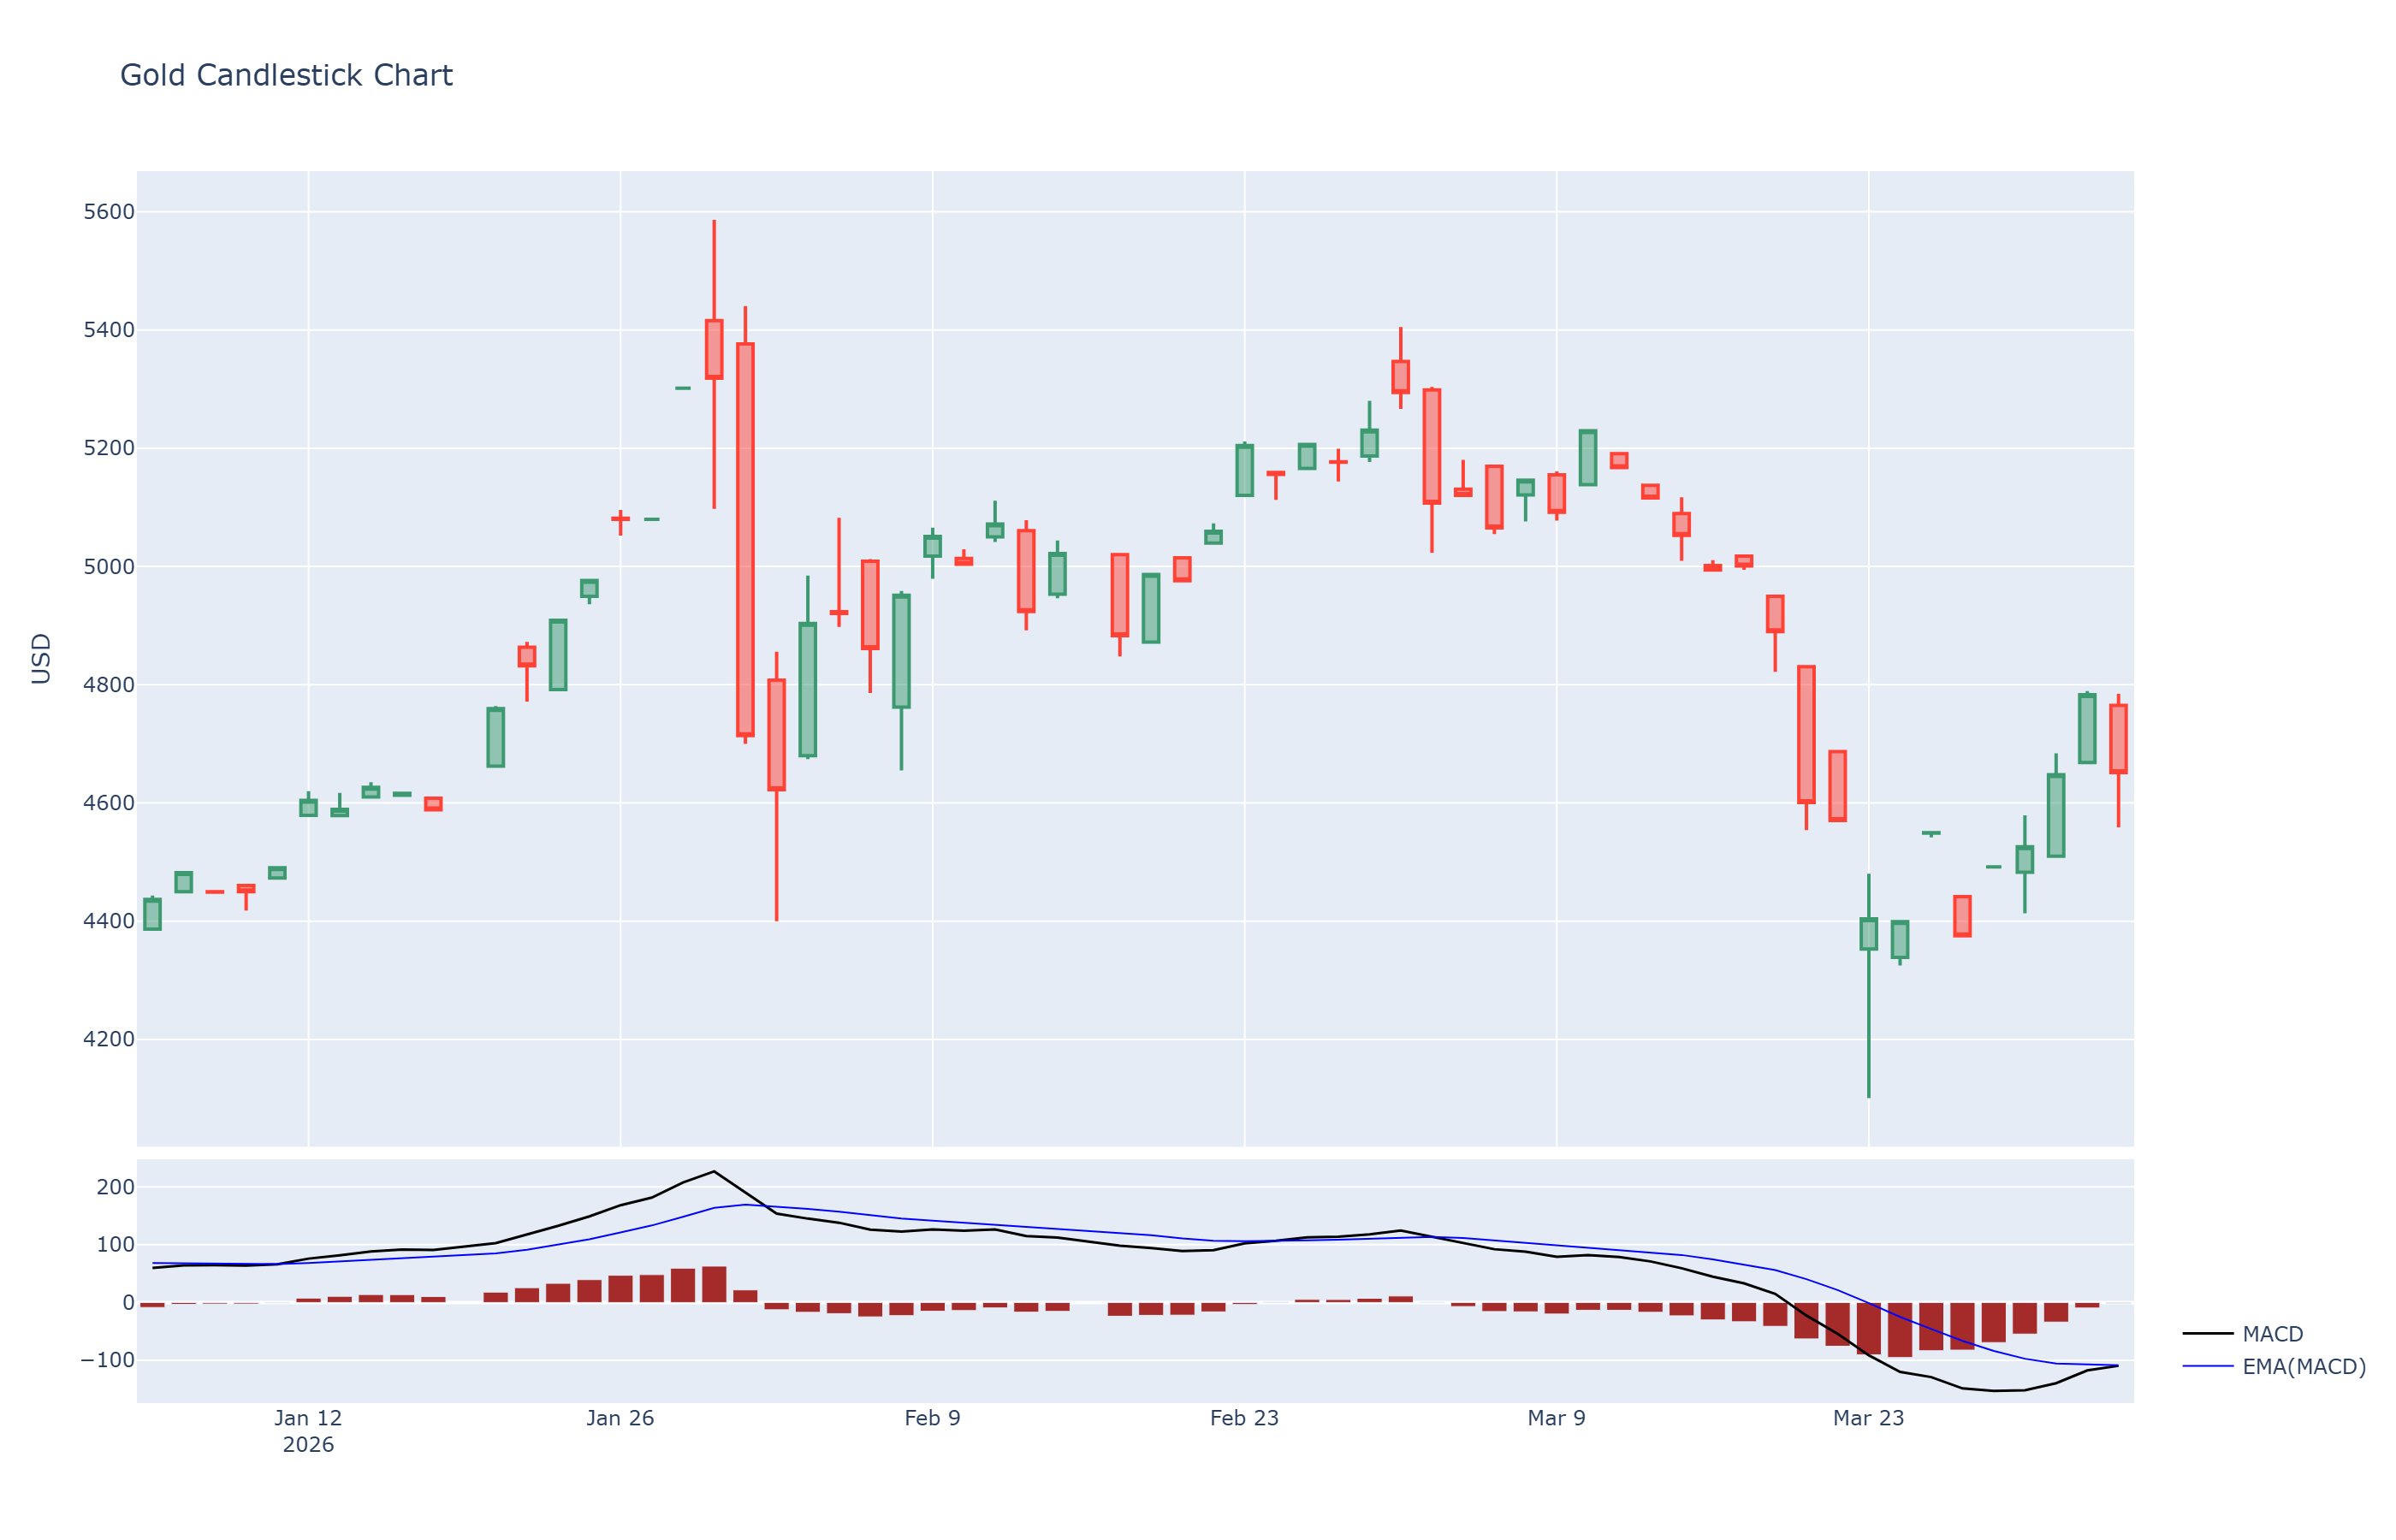

Open interest in Gold is 265,936 contracts
Gold's latest RSI reading is 45 (neutral)


In [15]:
def main():
    commodities = ["CC=F", "KC=F", "GC=F"]
    for contract in commodities:
        data = futures_data(contract)
        technicals = technical_analysis(data["prices"])
        plot_futures(data["prices"], technicals["macd"], data["currency"], data["name"])
        print(f"Open interest in {data['name']} is {data['open_interest']:,.0f} contracts")
        if technicals['rsi'] < 30:
            print(f"{data['name']}'s latest RSI reading is {round(technicals['rsi'])} (oversold)")
        elif technicals['rsi'] > 70:
            print(f"{data['name']}'s latest RSI reading is {round(technicals['rsi'])} (overbought)")
        else:
            print(f"{data['name']}'s latest RSI reading is {round(technicals['rsi'])} (neutral)")

if __name__ == "__main__":
    main()